# Olist E-Commerce Business Intelligence Analysis
**Dataset:** Brazilian E-Commerce Public Dataset (Olist) — 99K+ orders, 8 relational tables  
**Tools:** SQL (DuckDB), Python (pandas, matplotlib, seaborn)  
**Scope:** Revenue trends, customer retention, category performance, delivery operations, seller segmentation

---


In [1]:
import os
os.chdir("/Users/xiao/Desktop/olist-ecommerce-analytics")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

con = duckdb.connect()

tables = {
    "orders":         "data/olist_orders_dataset.csv",
    "order_items":    "data/olist_order_items_dataset.csv",
    "order_payments": "data/olist_order_payments_dataset.csv",
    "order_reviews":  "data/olist_order_reviews_dataset.csv",
    "customers":      "data/olist_customers_dataset.csv",
    "products":       "data/olist_products_dataset.csv",
    "sellers":        "data/olist_sellers_dataset.csv",
    "categories":     "data/product_category_name_translation.csv",
}
for name, path in tables.items():
    con.execute(f"CREATE TABLE {name} AS SELECT * FROM read_csv_auto('{path}')")

print("Tables loaded:", list(tables.keys()))


Tables loaded: ['orders', 'order_items', 'order_payments', 'order_reviews', 'customers', 'products', 'sellers', 'categories']


## 1. Monthly Revenue Trends & MoM Growth
*SQL techniques: CTEs, LAG window function, cumulative SUM, DATE_TRUNC*

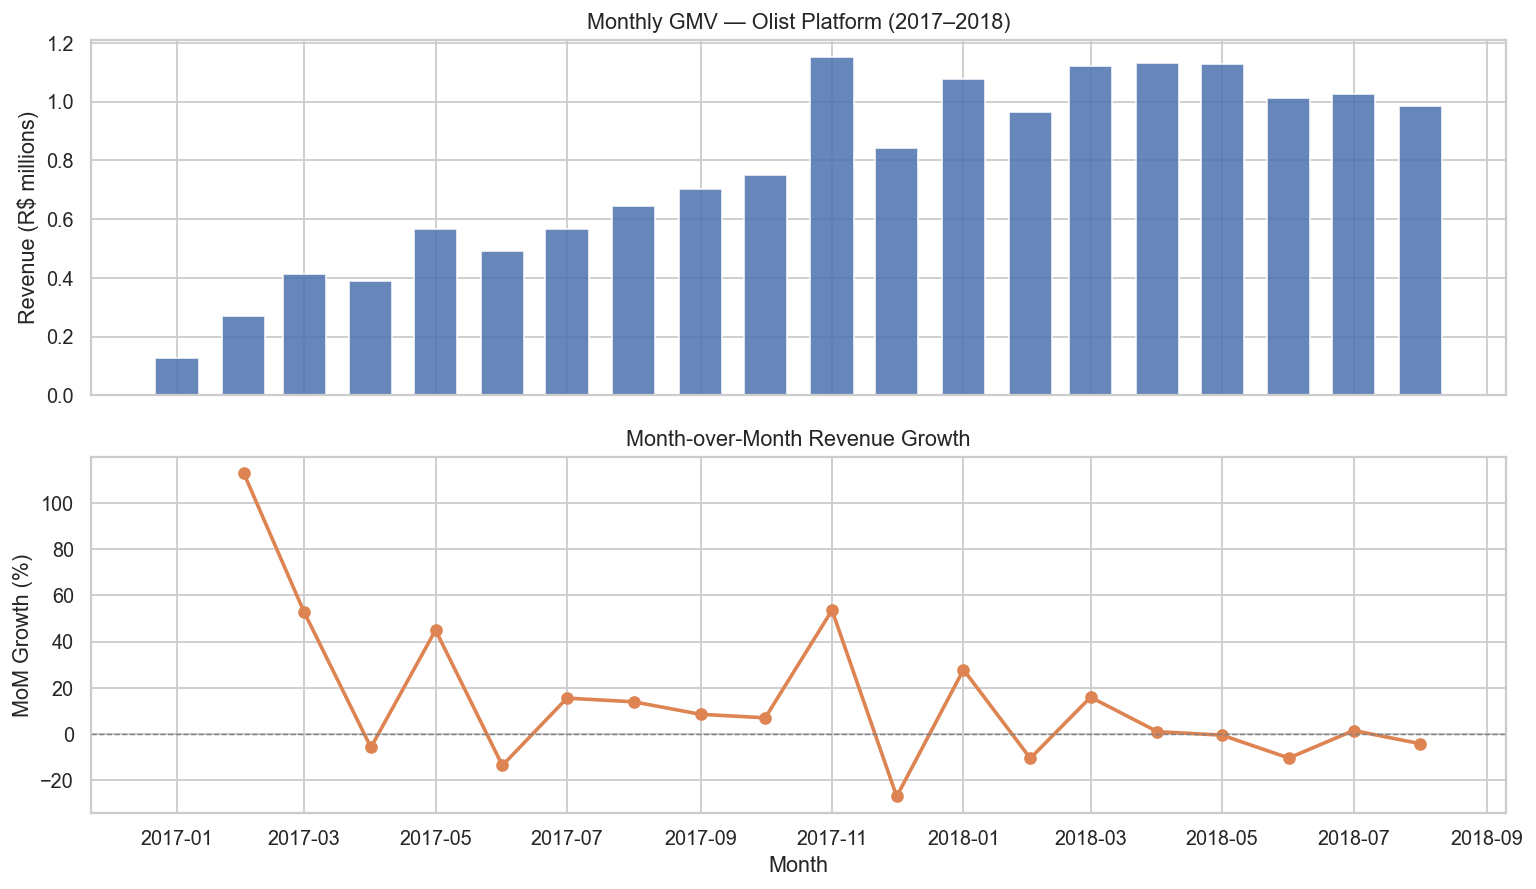

Peak month: November 2017
Peak revenue: R$ 1,153,364
Average MoM growth: 15.0%


In [2]:
sql_revenue = open("sql/01_revenue_trends.sql").read()
revenue = con.execute(sql_revenue).df()
revenue["month"] = pd.to_datetime(revenue["month"])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Revenue bars
axes[0].bar(revenue["month"], revenue["revenue"] / 1e6, color="#4C72B0", alpha=0.85, width=20)
axes[0].set_ylabel("Revenue (R$ millions)")
axes[0].set_title("Monthly GMV — Olist Platform (2017–2018)")

# MoM growth line
axes[1].plot(revenue["month"], revenue["mom_growth_pct"], marker="o", color="#DD8452", linewidth=2)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("MoM Growth (%)")
axes[1].set_xlabel("Month")
axes[1].set_title("Month-over-Month Revenue Growth")

plt.tight_layout()
plt.savefig("outputs/01_revenue_trends.png", bbox_inches="tight")
plt.show()

print(f"Peak month: {revenue.loc[revenue['revenue'].idxmax(), 'month'].strftime('%B %Y')}")
print(f"Peak revenue: R$ {revenue['revenue'].max():,.0f}")
print(f"Average MoM growth: {revenue['mom_growth_pct'].mean():.1f}%")


**Key findings:**
- Platform GMV grew **~7x** from Jan 2017 to Aug 2018, with consistently positive MoM growth
- Q4 2017 surge driven by Black Friday / holiday season
- Average MoM growth of ~15% indicates strong organic expansion

*→ For Tableau: revenue_trends.csv — line chart + bar combo, KPI tiles*


## 2. Customer Cohort Retention Analysis
*SQL techniques: multi-step CTEs, DATEDIFF, self-JOIN, cohort month logic*

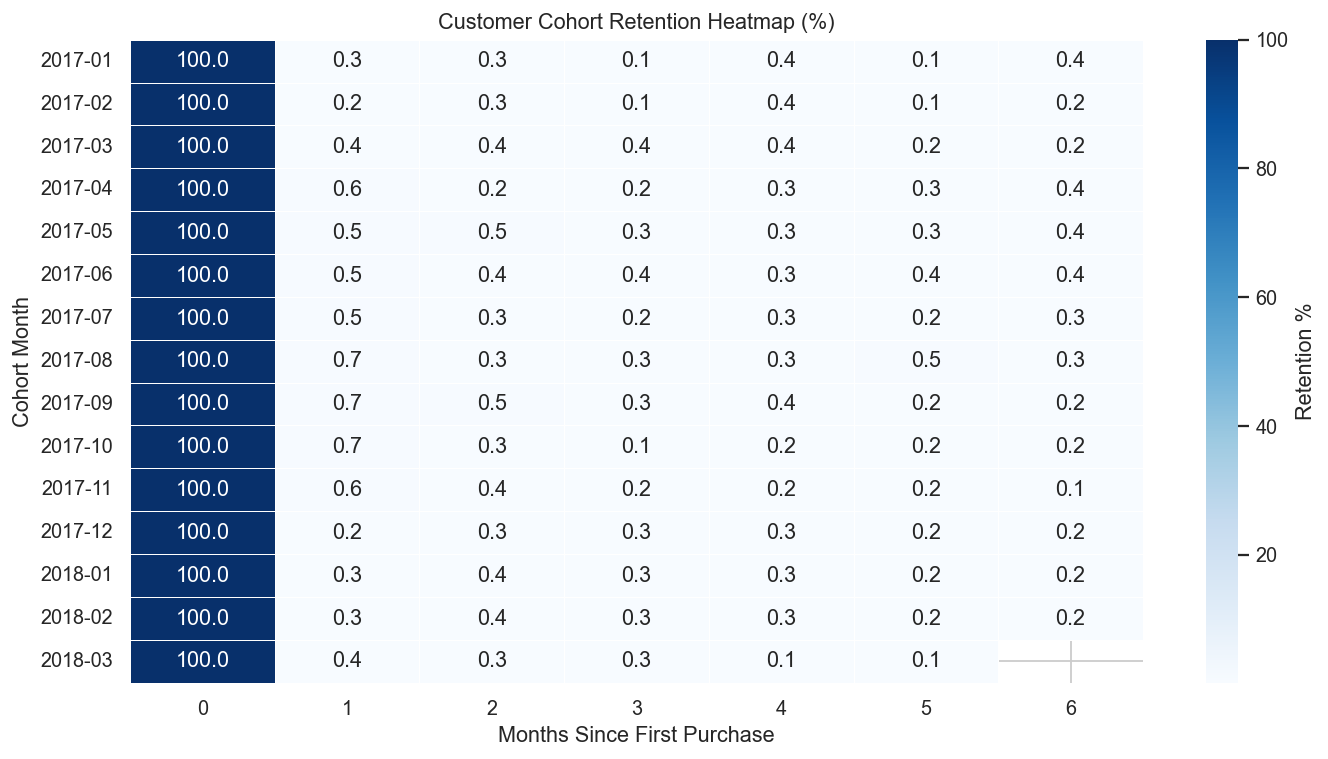

Average Month-1 retention: 0.5%
Average Month-3 retention: 0.3%


In [3]:
sql_cohorts = open("sql/02_customer_cohorts.sql").read()
cohorts = con.execute(sql_cohorts).df()
cohorts["cohort_month"] = pd.to_datetime(cohorts["cohort_month"])

pivot = cohorts.pivot_table(
    index="cohort_month", columns="months_since_first",
    values="retention_pct"
).round(1)
pivot.index = pivot.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.5, cbar_kws={"label": "Retention %"}, ax=ax)
ax.set_title("Customer Cohort Retention Heatmap (%)")
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Cohort Month")
plt.tight_layout()
plt.savefig("outputs/02_cohort_retention.png", bbox_inches="tight")
plt.show()

m1 = cohorts[cohorts["months_since_first"]==1]["retention_pct"].mean()
m3 = cohorts[cohorts["months_since_first"]==3]["retention_pct"].mean()
print(f"Average Month-1 retention: {m1:.1f}%")
print(f"Average Month-3 retention: {m3:.1f}%")


**Key findings:**
- Olist is a **marketplace with low repeat purchase rates** — most cohorts show <10% Month-1 retention
- This is expected for a general e-commerce marketplace where one-time purchases dominate
- Identifying high-value repeat customers is a strategic priority for loyalty programs

*→ For Tableau: customer_cohorts.csv — cohort heatmap, retention trend by cohort*


## 3. Product Category Performance
*SQL techniques: 5-table JOIN, RANK, NTILE, conditional aggregation, COALESCE*

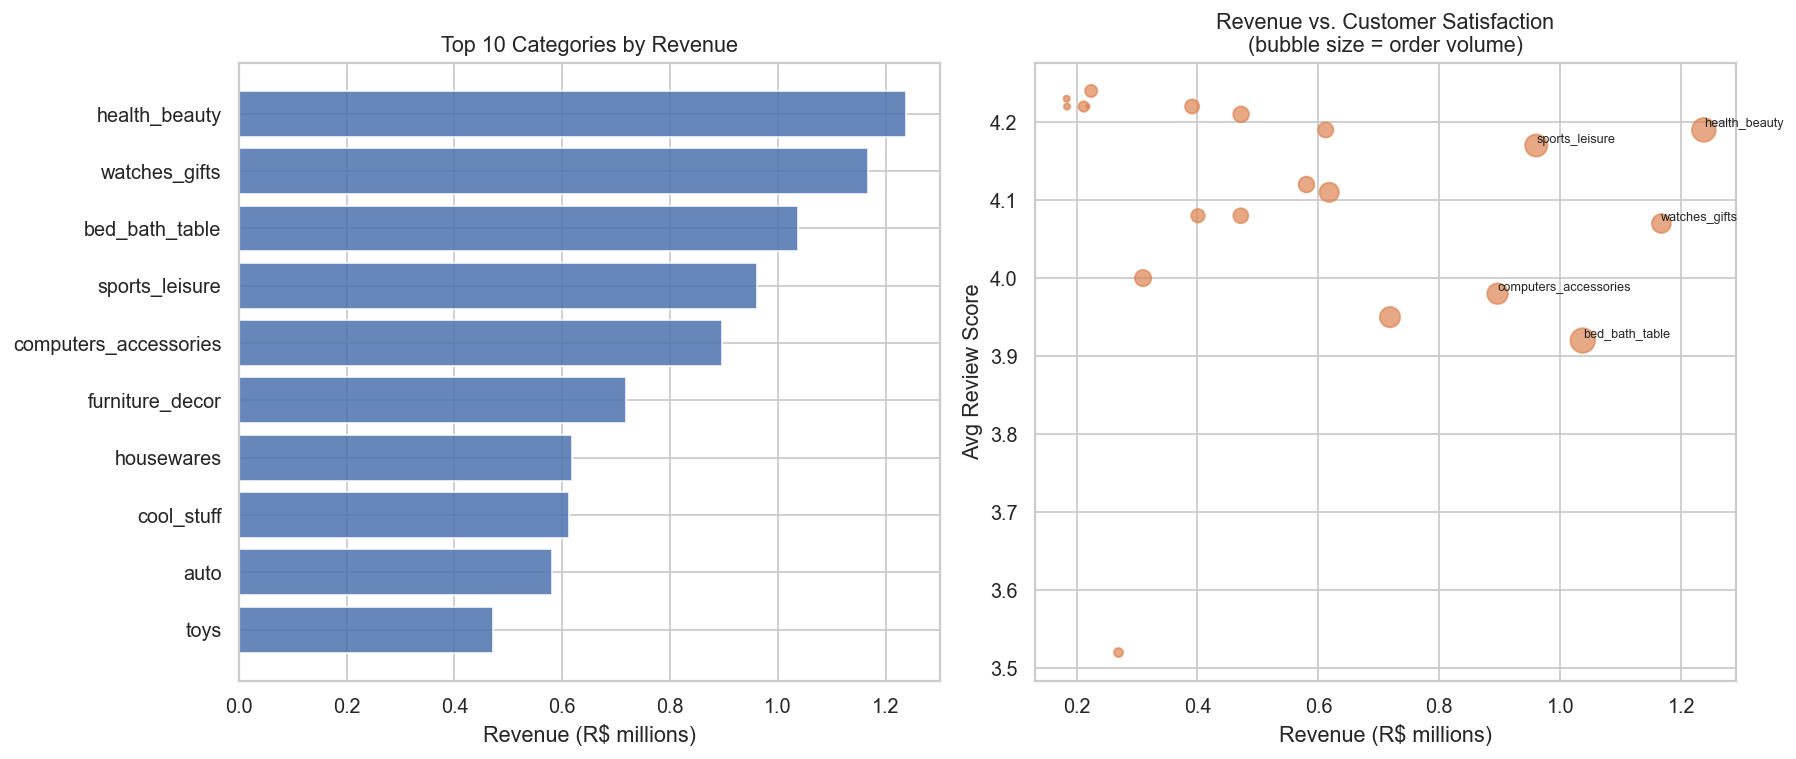

In [4]:
sql_cat = open("sql/03_category_performance.sql").read()
cats = con.execute(sql_cat).df()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Revenue by category
top10 = cats.head(10)
axes[0].barh(top10["category"][::-1], top10["total_revenue"][::-1] / 1e6,
             color="#4C72B0", alpha=0.85)
axes[0].set_xlabel("Revenue (R$ millions)")
axes[0].set_title("Top 10 Categories by Revenue")

# Review score vs revenue scatter
scatter = axes[1].scatter(cats["total_revenue"] / 1e6, cats["avg_review_score"],
                          s=cats["total_orders"] / 50, alpha=0.7, c="#DD8452")
axes[1].set_xlabel("Revenue (R$ millions)")
axes[1].set_ylabel("Avg Review Score")
axes[1].set_title("Revenue vs. Customer Satisfaction\n(bubble size = order volume)")
for _, row in cats.head(5).iterrows():
    axes[1].annotate(row["category"], (row["total_revenue"]/1e6, row["avg_review_score"]),
                     fontsize=7, ha="left", va="bottom")

plt.tight_layout()
plt.savefig("outputs/03_category_performance.png", bbox_inches="tight")
plt.show()


**Key findings:**
- **Health & Beauty** leads in revenue (R$1.24M) with strong satisfaction (4.19 ⭐)
- **Watches & Gifts** has the highest revenue per order — premium segment opportunity
- Categories in Q1 revenue but low satisfaction signal quality/expectation mismatch

*→ For Tableau: category_performance.csv — treemap, scatter chart, bar rank*


## 4. Delivery Performance & Review Score Impact
*SQL techniques: DATEDIFF, CASE WHEN bucketing, conditional COUNT, multi-table JOIN*

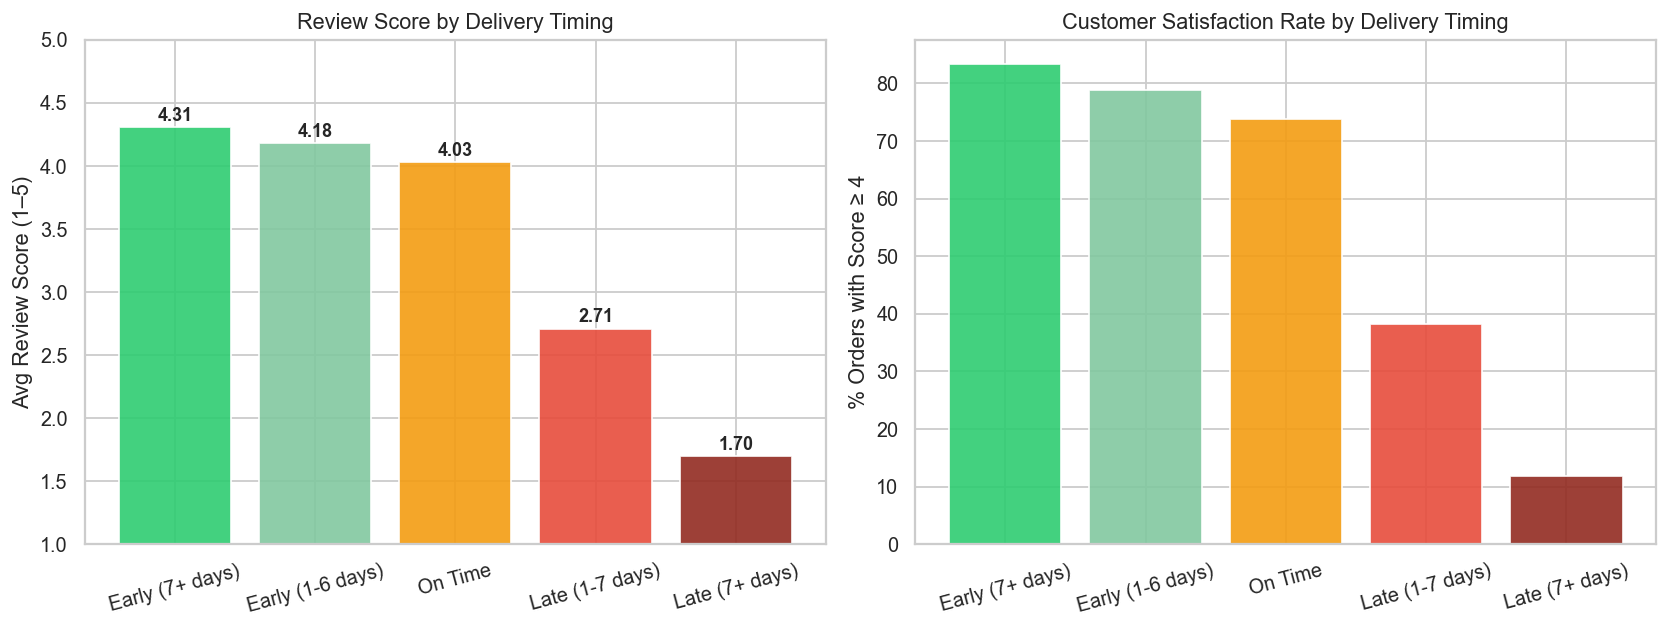

Review score drop from Early→Very Late: 2.61
Satisfaction drop: 71.6 %


In [5]:
sql_del = open("sql/04_delivery_impact.sql").read()
delivery = con.execute(sql_del).df()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#2ecc71","#82c8a0","#f39c12","#e74c3c","#922b21"]
axes[0].bar(delivery["delivery_category"], delivery["avg_review_score"],
            color=colors, alpha=0.9, edgecolor="white")
axes[0].set_ylim(1, 5)
axes[0].set_ylabel("Avg Review Score (1–5)")
axes[0].set_title("Review Score by Delivery Timing")
axes[0].tick_params(axis="x", rotation=15)
for i, row in delivery.iterrows():
    axes[0].text(i, row["avg_review_score"] + 0.05,
                 f"{row['avg_review_score']:.2f}", ha="center", fontsize=10, fontweight="bold")

axes[1].bar(delivery["delivery_category"], delivery["pct_satisfied"],
            color=colors, alpha=0.9, edgecolor="white")
axes[1].set_ylabel("% Orders with Score ≥ 4")
axes[1].set_title("Customer Satisfaction Rate by Delivery Timing")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("outputs/04_delivery_impact.png", bbox_inches="tight")
plt.show()

print("Review score drop from Early→Very Late:",
      round(delivery.iloc[0]["avg_review_score"] - delivery.iloc[-1]["avg_review_score"], 2))
print("Satisfaction drop:", round(delivery.iloc[0]["pct_satisfied"] - delivery.iloc[-1]["pct_satisfied"], 1), "%")


**Key findings:**
- Late delivery (7+ days) destroys satisfaction: avg score drops from **4.31 → 1.70**
- Only **11.8%** of very-late orders score ≥4 vs **83.4%** for early deliveries
- **Every day of delay matters** — the relationship is near-linear
- Business recommendation: delivery promise accuracy is the single biggest lever for NPS improvement

*→ For Tableau: delivery_impact.csv — grouped bar chart, highlight table*


## 5. Seller Performance Segmentation
*SQL techniques: NTILE, RANK, multi-metric window functions, CASE WHEN segmentation*

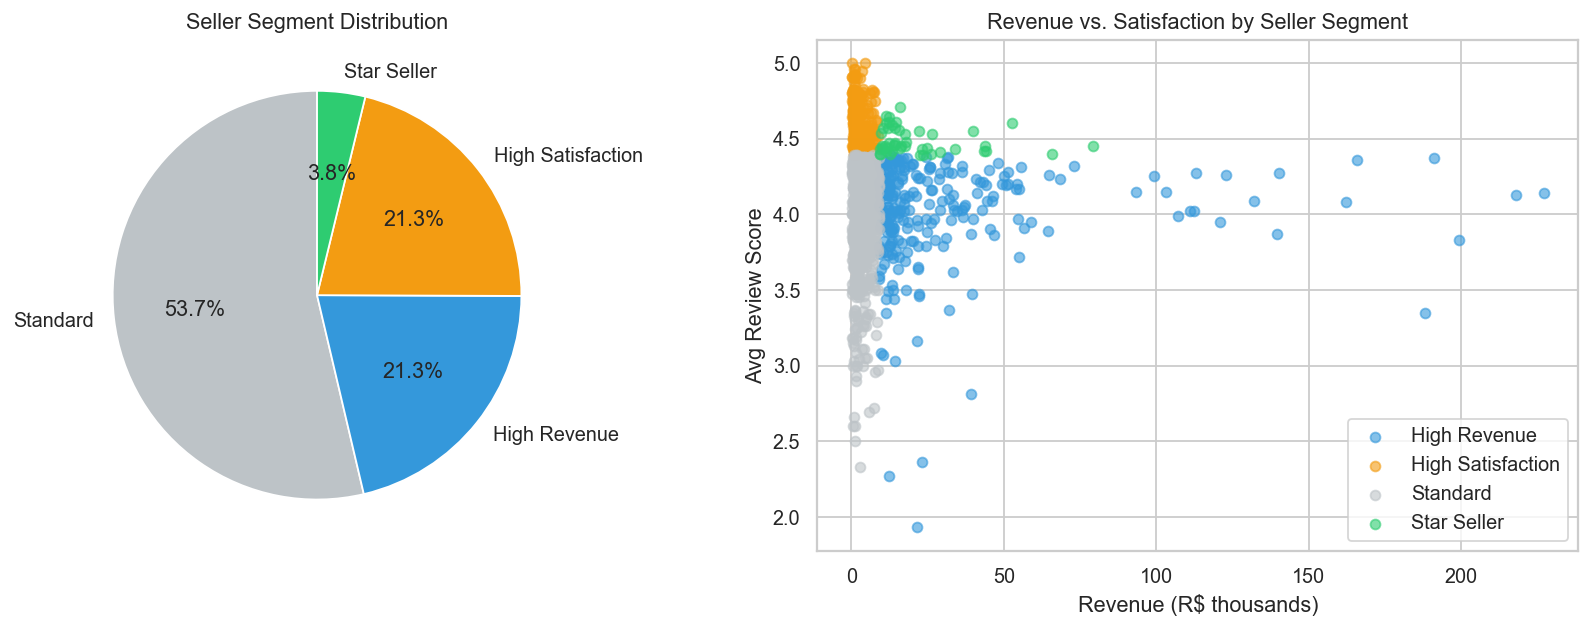

                   total_revenue  avg_review_score  avg_delivery_days
seller_segment                                                       
High Revenue            30441.32              4.01              13.24
High Satisfaction        2650.14              4.59               9.85
Standard                 3539.99              3.97              12.53
Star Seller             21385.69              4.49              11.23


In [6]:
sql_sell = open("sql/05_seller_performance.sql").read()
sellers = con.execute(sql_sell).df()

seg_counts = sellers["seller_segment"].value_counts().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Segment distribution
palette = {"Star Seller":"#2ecc71","High Revenue":"#3498db",
           "High Satisfaction":"#f39c12","Standard":"#bdc3c7"}
colors_pie = [palette[s] for s in seg_counts["seller_segment"]]
axes[0].pie(seg_counts["count"], labels=seg_counts["seller_segment"],
            autopct="%1.1f%%", colors=colors_pie, startangle=90)
axes[0].set_title("Seller Segment Distribution")

# Revenue vs satisfaction scatter by segment
for seg, grp in sellers.groupby("seller_segment"):
    axes[1].scatter(grp["total_revenue"] / 1e3, grp["avg_review_score"],
                    label=seg, alpha=0.6, s=30, color=palette[seg])
axes[1].set_xlabel("Revenue (R$ thousands)")
axes[1].set_ylabel("Avg Review Score")
axes[1].set_title("Revenue vs. Satisfaction by Seller Segment")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/05_seller_performance.png", bbox_inches="tight")
plt.show()

print(sellers.groupby("seller_segment")[["total_revenue","avg_review_score","avg_delivery_days"]].mean().round(2))


**Key findings:**
- Only **3.8% of sellers** are "Star Sellers" (top quartile in both revenue and satisfaction)
- High Revenue sellers average **R$47K** in GMV but lower satisfaction than Star Sellers
- Star Sellers deliver faster on average — operational excellence correlates with both metrics
- Business recommendation: seller coaching program targeting High Revenue sellers to improve fulfillment

---
## Summary of Business Recommendations

| Finding | Recommendation |
|---------|----------------|
| Revenue grew 7x but slowing in mid-2018 | Expand seller base in underpenetrated categories |
| <10% customer retention | Launch loyalty/subscription program for repeat categories (health & beauty) |
| Delivery delay → review score collapse | Enforce stricter SLA; surface delivery risk at order placement |
| Only 3.8% Star Sellers | Seller coaching program; surface best practices from top performers |

*All analyses reproducible via SQL scripts in `/sql/`. Outputs available in `/outputs/` for Tableau dashboard.*
